<a href="https://colab.research.google.com/github/mukulbawane/Python-Libraries/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Netflix** **Review**

In [1]:
# import essential libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("netflix_titles.csv")

In [2]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1819,s1820,Movie,Ghadi,Amin Dora,"Georges Khabbaz, Lara Rain, Emmanuel Khairalla...",Lebanon,"October 19, 2020",2013,TV-MA,101 min,"Comedies, Dramas, International Movies",When the father of a boy with Down syndrome re...
314,s315,Movie,Heavy,James Mangold,"Pruitt Taylor Vince, Shelley Winters, Liv Tyle...",United States,"August 3, 2021",1995,R,104 min,"Dramas, Independent Movies, Romantic Movies",Overweight Victor hides from the world making ...
4152,s4153,Movie,Bhasmasur,Nishil Sheth,"Imran Rasheed, Mittal Chouhan, Trimala Adhikar...",India,"January 29, 2019",2017,TV-14,74 min,"Dramas, Independent Movies, International Movies","In this heart-wrenching coming-of-age story, a..."
1102,s1103,Movie,Accepted,Steve Pink,"Justin Long, Jonah Hill, Adam Herschman, Colum...",United States,"April 2, 2021",2006,PG-13,93 min,Comedies,"Rejected by every college he applied to, a hig..."
1304,s1305,Movie,Animals on the Loose: A You vs. Wild Movie,Ben Simms,Bear Grylls,United States,"February 16, 2021",2021,TV-PG,139 min,Children & Family Movies,"When wild animals escape from a sanctuary, Bea..."


In [4]:
# check the length of data

len(df)

8807

In [5]:
# checking data types

df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [5]:
# number of unique value in our data

for i in df.columns:
  print(i,':',df[i].nunique())


# df.nunique()

show_id : 8807
type : 2
title : 8807
director : 4528
cast : 7692
country : 748
date_added : 1767
release_year : 74
rating : 17
duration : 220
listed_in : 514
description : 8775


In [6]:
# checking null value in every column of our data

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
# checking the occurance of each of the rating

df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [10]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [2]:
# using stacking

#unnesting the directors column, i.e- creating separate lines for each director in a movie

# making seperate row for each directoe and cast

constraint1 = df['director'].apply(lambda x: str(x).split(',')).to_list()

constraint1[:20]

[['Kirsten Johnson'],
 ['nan'],
 ['Julien Leclercq'],
 ['nan'],
 ['nan'],
 ['Mike Flanagan'],
 ['Robert Cullen', ' José Luis Ucha'],
 ['Haile Gerima'],
 ['Andy Devonshire'],
 ['Theodore Melfi'],
 ['nan'],
 ['Kongkiat Komesiri'],
 ['Christian Schwochow'],
 ['Bruno Garotti'],
 ['nan'],
 ['nan'],
 ['Pedro de Echave García', ' Pablo Azorín Williams'],
 ['nan'],
 ['Adam Salky'],
 ['nan']]

In [3]:
df_new1 = pd.DataFrame(constraint1, index= df['title'])
df_new1.head(10)

,0,1,2,3,4,5,6,7,8,9,10
title,,,,,,,,,,,
Dick Johnson Is Dead,Kirsten Johnson,None,None,None,None,None,None,None,None,None,None
Blood & Water,nan,None,None,None,None,None,None,None,None,None,None
Ganglands,Julien Leclercq,None,None,None,None,None,None,None,None,None,None
Jailbirds New Orleans,nan,None,None,None,None,None,None,None,None,None,None
Kota Factory,nan,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Mike Flanagan,None,None,None,None,None,None,None,None,None,None
My Little Pony: A New Generation,Robert Cullen,José Luis Ucha,None,None,None,None,None,None,None,None,None
Sankofa,Haile Gerima,None,None,None,None,None,None,None,None,None,None
The Great British Baking Show,Andy Devonshire,None,None,None,None,None,None,None,None,None,None


In [4]:
df_new1=df_new1.stack()
# print(df_new1["My Little Pony: A New Generation"])
# print()
# print(df_new1["My Little Pony: A New Generation"][0])
# print(df_new1["My Little Pony: A New Generation"][1])
# print("\n\n")
df_new1.head(10)

title                              
Dick Johnson Is Dead              0    Kirsten Johnson
Blood & Water                     0                nan
Ganglands                         0    Julien Leclercq
Jailbirds New Orleans             0                nan
Kota Factory                      0                nan
Midnight Mass                     0      Mike Flanagan
My Little Pony: A New Generation  0      Robert Cullen
                                  1     José Luis Ucha
Sankofa                           0       Haile Gerima
The Great British Baking Show     0    Andy Devonshire
dtype: object

In [5]:
df_new1=pd.DataFrame(df_new1.reset_index())
df_new1.rename(columns={0:'Directors'},inplace=True)
df_new1.head(10)

,title,level_1,Directors
0,Dick Johnson Is Dead,0,Kirsten Johnson
1,Blood & Water,0,nan
2,Ganglands,0,Julien Leclercq
3,Jailbirds New Orleans,0,nan
4,Kota Factory,0,nan
5,Midnight Mass,0,Mike Flanagan
6,My Little Pony: A New Generation,0,Robert Cullen
7,My Little Pony: A New Generation,1,José Luis Ucha
8,Sankofa,0,Haile Gerima
9,The Great British Baking Show,0,Andy Devonshire


In [6]:
df_new1.drop(['level_1'], axis=1, inplace=True)
df_new1.head(10)

,title,Directors
0,Dick Johnson Is Dead,Kirsten Johnson
1,Blood & Water,nan
2,Ganglands,Julien Leclercq
3,Jailbirds New Orleans,nan
4,Kota Factory,nan
5,Midnight Mass,Mike Flanagan
6,My Little Pony: A New Generation,Robert Cullen
7,My Little Pony: A New Generation,José Luis Ucha
8,Sankofa,Haile Gerima
9,The Great British Baking Show,Andy Devonshire


In [7]:
# exploding

toy_df = df[['title', 'director']]
toy_df.head(10)

,title,director
0,Dick Johnson Is Dead,Kirsten Johnson
1,Blood & Water,NaN
2,Ganglands,Julien Leclercq
3,Jailbirds New Orleans,NaN
4,Kota Factory,NaN
5,Midnight Mass,Mike Flanagan
6,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha"
7,Sankofa,Haile Gerima
8,The Great British Baking Show,Andy Devonshire
9,The Starling,Theodore Melfi


In [8]:
toy_df['director'] = toy_df['director'].apply(lambda x: str(x).split(',')).to_list()
toy_df.head(10)

<ipython-input-8-ee285489dcad>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toy_df['director'] = toy_df['director'].apply(lambda x: str(x).split(',')).to_list()


,title,director
0,Dick Johnson Is Dead,[Kirsten Johnson]
1,Blood & Water,[nan]
2,Ganglands,[Julien Leclercq]
3,Jailbirds New Orleans,[nan]
4,Kota Factory,[nan]
5,Midnight Mass,[Mike Flanagan]
6,My Little Pony: A New Generation,"[Robert Cullen, José Luis Ucha]"
7,Sankofa,[Haile Gerima]
8,The Great British Baking Show,[Andy Devonshire]
9,The Starling,[Theodore Melfi]


In [9]:
toy_df = toy_df.explode('director')
toy_df.head(10)

,title,director
0,Dick Johnson Is Dead,Kirsten Johnson
1,Blood & Water,nan
2,Ganglands,Julien Leclercq
3,Jailbirds New Orleans,nan
4,Kota Factory,nan
5,Midnight Mass,Mike Flanagan
6,My Little Pony: A New Generation,Robert Cullen
6,My Little Pony: A New Generation,José Luis Ucha
7,Sankofa,Haile Gerima
8,The Great British Baking Show,Andy Devonshire


In [10]:
df_new1.head(10)

,title,Directors
0,Dick Johnson Is Dead,Kirsten Johnson
1,Blood & Water,nan
2,Ganglands,Julien Leclercq
3,Jailbirds New Orleans,nan
4,Kota Factory,nan
5,Midnight Mass,Mike Flanagan
6,My Little Pony: A New Generation,Robert Cullen
7,My Little Pony: A New Generation,José Luis Ucha
8,Sankofa,Haile Gerima
9,The Great British Baking Show,Andy Devonshire


In [11]:
#unnesting the cast column, i.e- creating separate lines for each cast member in a movie


constraint2 = df['cast'].apply(lambda x: str(x).split(',')).to_list()
df_new2 = pd.DataFrame(constraint2, index=df['title'])
df_new2 = df_new2.stack()
df_new2 = pd.DataFrame(df_new2.reset_index())
df_new2.rename(columns={0:'Actor'}, inplace=True)
df_new2.drop('level_1', axis=1, inplace=True)
df_new2.head(10)

,title,Actor
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
5,Blood & Water,Dillon Windvogel
6,Blood & Water,Natasha Thahane
7,Blood & Water,Arno Greeff
8,Blood & Water,Xolile Tshabalala
9,Blood & Water,Getmore Sithole


In [12]:
#unnesting the listed_in column, i.e- creating separate lines for each cast member in a movie


constraint3 = df['listed_in'].apply(lambda x: str(x).split(',')).to_list()
df_new3 = pd.DataFrame(constraint3, index=df['title'])
df_new3 = df_new3.stack()
df_new3 = pd.DataFrame(df_new3.reset_index())
df_new3.rename(columns={0:'Genre'}, inplace=True)
df_new3.drop('level_1', axis=1, inplace=True)
df_new3.head(10)

,title,Genre
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,International TV Shows
2,Blood & Water,TV Dramas
3,Blood & Water,TV Mysteries
4,Ganglands,Crime TV Shows
5,Ganglands,International TV Shows
6,Ganglands,TV Action & Adventure
7,Jailbirds New Orleans,Docuseries
8,Jailbirds New Orleans,Reality TV
9,Kota Factory,International TV Shows


In [13]:
#unnesting the country column, i.e- creating separate lines for each cast member in a movie


constraint4 = df['country'].apply(lambda x: str(x).split(',')).to_list()
df_new4 = pd.DataFrame(constraint4, index=df['title'])
df_new4 = df_new4.stack()
df_new4 = pd.DataFrame(df_new4.reset_index())
df_new4.rename(columns={0:'country'}, inplace=True)
df_new4.drop('level_1', axis=1, inplace=True)
df_new4.head(5)

,title,country
0,Dick Johnson Is Dead,United States
1,Blood & Water,South Africa
2,Ganglands,nan
3,Jailbirds New Orleans,nan
4,Kota Factory,India


In [14]:
#merging the unnested director data with unnested actors data
df_new5 = df_new2.merge(df_new1, on=['title'], how='inner')


#merging the above merged data with unnested genre data
df_new6 = df_new5.merge(df_new3, on=['title'], how='inner')


#merging the above merged data with unnested country data
df_new = df_new6.merge(df_new4, on=['title'], how='inner')

df_new.sample(10)


# replacing nan values of director and actor by Unknown Actor and Unknown Director
df_new['Actor'].replace(['nan'], ['Unknown Actor'], inplace=True)
df_new['Directors'].replace(['nan'], ['Unknown Director'], inplace=True)
df_new['country'].replace(['nan'], [np.nan], inplace=True)

df_new.sample(10)

<ipython-input-14-d20edb3d72bb>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['Actor'].replace(['nan'], ['Unknown Actor'], inplace=True)
<ipython-input-14-d20edb3d72bb>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

,title,Actor,Directors,Genre,country
40764,Killer Cove,Dennis Staroselsky,Damián Romay,Thrillers,United States
1130,Jaws: The Revenge,Lynn Whitfield,Joseph Sargent,Horror Movies,United States
31563,The Conjuring 2,Simon Delaney,James Wan,Horror Movies,United States
62717,We'll Be Right Back After The Break,Maged El Kedwany,Ahmed Nader Galal,Action & Adventure,Egypt
16462,Ray,Radhika Madan,Vasan Bala,TV Dramas,NaN
68670,Full Count,Adam Boyer,Robert Eagar,Faith & Spirituality,United States
8773,The Losers,Óscar Jaenada,Sylvain White,Action & Adventure,France
23014,Au coeur des gangs,Tyrese Gibson,Vondie Curtis-Hall,Action & Adventure,United States
121668,Narcos,Brett Cullen,Unknown Director,TV Dramas,United States
80147,Haikyu!!,Hiroyuki Yoshino,Unknown Director,International TV Shows,Japan


In [15]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [15]:
#merging our unnested data with the original data

df_final = df_new.merge(df[['show_id', 'type', 'title', 'date_added', 'release_year', 'rating', 'duration', ]], on=['title'], how='left')
df_final.sample(10)

,title,Actor,Directors,Genre,country,show_id,type,date_added,release_year,rating,duration
84028,Steal a Pencil for Me,Ina Soep,Michèle Ohayon,Documentaries,United States,s3515,Movie,"September 15, 2019",2006.0,TV-14,94 min
77498,La Reina del Sur,Carmen Navarro,Unknown Director,Spanish-Language TV Shows,Colombia,s3213,TV Show,"November 29, 2019",2019.0,TV-MA,2 Seasons
100667,Dogs of Berlin,Alina Stiegler,Unknown Director,TV Dramas,Germany,s4317,TV Show,"December 7, 2018",2018.0,TV-MA,1 Season
116444,FullMetal Alchemist,Ryosuke Yamada,Fumihiko Sori,Action & Adventure,Japan,s5034,Movie,"February 19, 2018",2017.0,TV-PG,134 min
50534,Stranger,Joon-hyuk Lee,Unknown Director,Crime TV Shows,South Korea,s2123,TV Show,"August 16, 2020",2020.0,TV-MA,2 Seasons
37890,Torbaaz,Humayun Shams Khan,Girish Malik,International Movies,India,s1562,Movie,"December 11, 2020",2020.0,TV-MA,133 min
59421,Mutiny of the Worker Bees,Gustavo Egelhaaf,Carlos Morett,Comedies,Mexico,s2499,Movie,"May 20, 2020",2020.0,TV-MA,94 min
23438,Sitting in Limbo,CJ Beckford,Stella Corradi,International Movies,United Kingdom,s946,Movie,"May 1, 2021",2020.0,TV-MA,89 min
7401,Tango Feroz,Héctor Alterio,Marcelo Piñeyro,Classic Movies,Argentina,s306,Movie,"August 5, 2021",1993.0,TV-MA,124 min
33992,So My Grandma’s a Lesbian!,David Verdaguer,Ángeles Reiné,LGBTQ Movies,Spain,s1387,Movie,"January 22, 2021",2020.0,TV-MA,95 min


In [16]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', nan], dtype=object)

In duration column, it was observed that the nulls had values which were written in corresponding ratings column, i.e- you can't expect ratings to be in min. So the duration column nulls are replaced by corresponding values in ratings column

In [17]:
df['duration'].unique()

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [50]:
# the duration column nulls are replaced by corresponding values in ratings column
df_final.loc[df_final['duration'].isnull(), 'duration'] = df_final.loc[df_final['duration'].isnull(), 'duration'].fillna(df['rating'])
df_final.head()

<ipython-input-50-99cce022fee0>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final.loc[df_final['duration'].isnull(), 'duration'] = df_final.loc[df_final['duration'].isnull(), 'duration'].fillna(df['rating'])


,title,Actor,Directors,Genre,country,show_id,type,date_added,release_year,rating,duration,duration_copy
0,Dick Johnson Is Dead,Unknown Actor,Kirsten Johnson,Documentaries,United States,s1,Movie,"September 25, 2021",2020.0,PG-13,90,90
1,Blood & Water,Ama Qamata,Unknown Director,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,2 Seasons
2,Blood & Water,Ama Qamata,Unknown Director,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,2 Seasons
3,Blood & Water,Ama Qamata,Unknown Director,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,2 Seasons
4,Blood & Water,Khosi Ngema,Unknown Director,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,2 Seasons


In [19]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', nan], dtype=object)

In [51]:
#Ratings can't be in min, so it has been made NR(i.e- Non Rated)
df_final.loc[df_final['rating'].str.contains('min', na=False), 'rating'] = 'NR'
df_final['rating'].fillna('NR', inplace=True)

df_final.sample(10)

<ipython-input-51-9d799da13d7f>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['rating'].fillna('NR', inplace=True)


,title,Actor,Directors,Genre,country,show_id,type,date_added,release_year,rating,duration,duration_copy
79486,Shadow,Leo Wu,Zhang Yimou,Dramas,Hong Kong,s3303,Movie,"November 6, 2019",2018.0,TV-14,116,116
46130,The Boys in the Band: Something Personal,Brian Hutchison,Unknown Director,LGBTQ Movies,United States,s1933,Movie,"September 30, 2020",2020.0,TV-MA,28,28
33725,Outlander,Caitriona Balfe,Unknown Director,TV Action & Adventure,United States,s1378,TV Show,"January 27, 2021",2018.0,TV-MA,4 Seasons,4 Seasons
96722,Neevevaro,Tapsee Pannu,Hari Nath,Dramas,India,s4107,Movie,"February 15, 2019",2018.0,TV-14,132,132
66094,7SEEDS,Daisuke Sakaguchi,Unknown Director,Anime Series,United States,s2775,TV Show,"March 26, 2020",2020.0,TV-MA,2 Seasons,2 Seasons
47090,The Royal Bengal Tiger,Kharaj Mukherjee,Rajesh Ganguly,Thrillers,India,s1977,Movie,"September 19, 2020",2014.0,TV-MA,103,103
39590,Over Christmas,Johanna Gastdorf,Unknown Director,Romantic TV Shows,Germany,s1641,TV Show,"November 27, 2020",2020.0,TV-MA,1 Season,1 Season
31023,Our Idiot Brother,Paul Rudd,Jesse Peretz,Comedies,United States,s1265,Movie,"February 26, 2021",2011.0,R,90,90
63025,The Artist,Beth Grant,Michel Hazanavicius,Dramas,Belgium,s2635,Movie,"April 25, 2020",2011.0,PG-13,101,101
112358,Outside In,Edie Falco,Lynn Shelton,Dramas,United States,s4843,Movie,"June 1, 2018",2018.0,TV-MA,110,110


In [52]:
df_final[df_final['date_added'].isnull()].head()

,title,Actor,Directors,Genre,country,show_id,type,date_added,release_year,rating,duration,duration_copy
123895,NaN,Unknown Actor,Unknown Director,nan,United States,s5398,TV Sh,NaN,NaN,NR,NaN,nan


In [53]:
# filled missing `date_added` using `release_year`

df_final[df_final['date_added'].isnull()]['release_year'].unique()



array([nan])

In [54]:
i=2013
df_final[df_final['release_year']==i]['date_added'].mode()

,date_added
0,"July 5, 2020"


In [55]:
imp = df_final[df_final['release_year']==i]['date_added'].mode().values[0]
imp

'July 5, 2020'

In [56]:
df_final.loc[df_final['release_year']==i, 'date_added'].head()

,date_added
685,"September 19, 2021"
686,"September 19, 2021"
687,"September 19, 2021"
688,"September 19, 2021"
689,"September 19, 2021"


In [57]:
# finding out null in date added where release year = 2013
df_final.loc[df_final['release_year']==i, 'date_added'].isna().sum()


0

In [58]:
df_final.loc[df_final['release_year']==i, 'date_added'].fillna(imp)

,date_added
685,"September 19, 2021"
686,"September 19, 2021"
687,"September 19, 2021"
688,"September 19, 2021"
689,"September 19, 2021"
...,...
123307,"August 1, 2017"
123308,"August 1, 2017"
123309,"August 1, 2017"
123310,"August 1, 2017"


In [59]:
df_final.loc[df_final['release_year']==i, 'date_added'].fillna(imp).isna().sum()

0

In [ ]:
#date added column is imputed on the basis of release year,i.e- suppose there's a null for date_added
#when release year was 2013.So below piece of code just checks the mode of date added for release year=2013
# and imputes in place of nulls the corresponding mode

In [60]:
for i in df_final[df_final['date_added'].isnull()]['release_year'].unique():
  imp=df_final[df_final['release_year']==i]['date_added'].mode().values[0]
  df_final.loc[df_final['release_year']==i, 'date_added']= df_final.loc[df_final['release_year']==i, 'date_added'].fillna(imp)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [29]:
df_final['release_year'].unique()

array([2020, 2021, 1993, 2018, 1996, 1998, 1997, 2010, 2013, 2017, 1975,
       1978, 1983, 1987, 2012, 2001, 2014, 2002, 2003, 2004, 2011, 2008,
       2009, 2007, 2005, 2006, 1994, 2015, 2019, 2016, 1982, 1989, 1990,
       1991, 1999, 1986, 1992, 1984, 1980, 1961, 2000, 1995, 1985, 1976,
       1959, 1988, 1981, 1972, 1964, 1945, 1954, 1979, 1958, 1956, 1963,
       1970, 1973, 1925, 1974, 1960, 1966, 1971, 1962, 1969, 1977, 1967,
       1968, 1965, 1946, 1942, 1955, 1944, 1947, 1943])

In [ ]:
#country column is imputed on the basis of director,i.e- suppose there's a null for country
#when we have a director whose other movies have a country given.So below piece of code just checks the mode of
#country for the director and imputes in place of nulls the corresponding mode

In [32]:
for i in df_final[df_final['country'].isnull()]['Directors'].unique():
  if i in df_final[~df_final['country'].isnull()]['Directors'].unique():
    imp=df_final[df_final["Directors"]==i]['country'].mode().values[0]
    df_final.loc[df_final["Directors"]==i, 'country']=df_final.loc[df_final["Directors"]==i, 'country'].fillna(imp)

In [33]:
df_final.head()

,title,Actor,Directors,Genre,country,show_id,type,date_added,release_year,rating,duration
0,Dick Johnson Is Dead,Unknown Actor,Kirsten Johnson,Documentaries,United States,s1,Movie,"September 25, 2021",2020.0,PG-13,90 min
1,Blood & Water,Ama Qamata,Unknown Director,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons
2,Blood & Water,Ama Qamata,Unknown Director,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons
3,Blood & Water,Ama Qamata,Unknown Director,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons
4,Blood & Water,Khosi Ngema,Unknown Director,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons


So we imputed the country column on the basis of directors whose other movie titles had countries given. But there might be directors who have only one occurence in our data. In that scenario, I have used Actors as a basis. i.e- for this Actor majorly acts in movies of which country? Imputation has been done on this basis. For remaining rows, country has been filled as Unknown Country

In [34]:
for i in df_final[df_final['country'].isnull()]['Actor'].unique():
  if i in df_final[~df_final['country'].isnull()]['Actor'].unique():
    imp=df_final[df_final['Actor']==i]['country'].mode().values[0]
    df_final.loc[df_final['Actor']==i, 'country']=df_final.loc[df_final['Actor']==i, 'country'].fillna(imp)

#If there are still nulls, I just replace it by Unknown Country
df_final['country'].fillna('Unknown Country', inplace=True)
df_final.isnull().sum()

<ipython-input-34-815ce10e7d22>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['country'].fillna('Unknown Country', inplace=True)


,0
title,1
Actor,0
Directors,0
Genre,0
country,0
show_id,0
type,0
date_added,1
release_year,1
rating,0


In [36]:
df_final['duration'].value_counts()

,count
duration,
1 Season,35035
2 Seasons,9559
3 Seasons,5084
94 min,4343
106 min,4040
...,...
3 min,4
5 min,3
11 min,2


In [35]:
# Removing 'min' from duration field

df_final['duration'] = df_final['duration'].str.replace('min', ' ')
df_final.head()

,title,Actor,Directors,Genre,country,show_id,type,date_added,release_year,rating,duration
0,Dick Johnson Is Dead,Unknown Actor,Kirsten Johnson,Documentaries,United States,s1,Movie,"September 25, 2021",2020.0,PG-13,90
1,Blood & Water,Ama Qamata,Unknown Director,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons
2,Blood & Water,Ama Qamata,Unknown Director,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons
3,Blood & Water,Ama Qamata,Unknown Director,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons
4,Blood & Water,Khosi Ngema,Unknown Director,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons


In [64]:
df_final1['duration'].isna().sum()

1

In [46]:
df_final['duration_copy'] = df_final['duration'].copy()
df_final1 = df_final.copy()

In [63]:
df_final1.loc[df_final1['duration_copy'].str.contains('Seasons'), 'duration_copy'] = 0
df_final1['duration_copy'] = df_final1['duration_copy'].astype('int')
df_final1.head()

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [42]:
df_final1['duration_copy'].describe()

,duration_copy
count,123896
unique,196
top,0
freq,43648


<ipython-input-43-dfa455b98ddc>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_final1['duration_copy'], hist=True, kde=True,


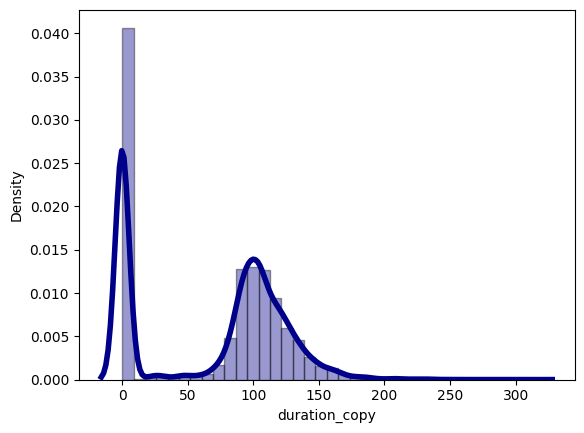

In [43]:
import seaborn as sns
sns.distplot(df_final1['duration_copy'], hist=True, kde=True,
bins=int(36), color = 'darkblue',
hist_kws={'edgecolor':'black'},
kde_kws={'linewidth': 4})
plt.show()

In [45]:
# creating bins for duration

bins1 = [-1,1,50,80,100,120,150,200,315]
labels1 = ['<1', '1-50', '50-80', '80-100', '100-120', '120-150', '150-200', '200-315']

df_final1['duration_copy'] = pd.cut(df_final1['duration_copy'], bins=bins1, labels=labels1)

df_final1.head()

TypeError: '<' not supported between instances of 'int' and 'str'

In [67]:
from datetime import datetime
from dateutil.parser import parse

arr=[]
for i in df_final1['date_added'].values:
  dt1=parse(i)
  arr.append(dt1.strftime('%Y-%m-%d'))
df_final1['Modified_Added_date'] = arr
df_final1['Modified_Added_date'] = pd.to_datetime(df_final1['Modified_Added_date'])
df_final1['month_added']=df_final1['Modified_Added_date'].dt.month
df_final1['week_added']=df_final1['Modified_Added_date'].dt.week
df_final1['year']=df_final1['Modified_Added_date'].dt.year
df_final1.head()


TypeError: Parser must be a string or character stream, not float

In [68]:
#Titles such as Bahubali(Hindi Version),Bahubali(Tamil Version) were there. Since it's only one movie in different languages,
#presence of brackets and content between brackets is removed.
df_final1['title']=df_final1['title'].str.replace(r"\(.*\)","")
df_final1.head()

,title,Actor,Directors,Genre,country,show_id,type,date_added,release_year,rating,duration,duration_copy
0,Dick Johnson Is Dead,Unknown Actor,Kirsten Johnson,Documentaries,United States,s1,Movie,"September 25, 2021",2020.0,PG-13,90,90
1,Blood & Water,Ama Qamata,Unknown Director,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,0
2,Blood & Water,Ama Qamata,Unknown Director,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,0
3,Blood & Water,Ama Qamata,Unknown Director,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,0
4,Blood & Water,Khosi Ngema,Unknown Director,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021.0,TV-MA,2 Seasons,0


In [69]:
#number of distinct titles on the basis of genre
df_final1.groupby(['Genre']).agg({"title":"nunique"})

,title
Genre,
Anime Features,38
Children & Family Movies,20
Classic & Cult TV,4
Classic Movies,14
Comedies,269
...,...
TV Horror,8
TV Sci-Fi & Fantasy,1
TV Shows,11
